# **Tendència de Dies Ventats a Sabadell Nord**

Aquest notebook analitza l'evolució dels dies més ventats a l'estació de **Sabadell Nord** (dades de 30 min) al llarg dels anys.

**Metodologia:**
- Per cada dia, agafem l'interval de 30 min amb `avg_wind_kmh` més alt
- De cada any, seleccionem els **20 dies** amb el vent mitjà diari més alt
- Visualitzem la tendència amb un boxplot anual + línia de la mediana
- Analitzem a quina hora del dia i en quins mesos es produeixen els pics de vent

## 1. Càrrega i Preparació de Dades

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Carregar dades horàries de Sabadell Nord
df = pd.read_csv('https://raw.githubusercontent.com/DavidDDRC99/VO-evolution/refs/heads/main/Cleaned%20Data/Sbd_nord_hourly.csv')

# Parse datetime
df['datetime_utc'] = pd.to_datetime(df['datetime_utc'])

# Extreure components
df['hour'] = df['datetime_utc'].dt.hour
df['minute'] = df['datetime_utc'].dt.minute
df['month'] = df['datetime_utc'].dt.month
df['day'] = df['datetime_utc'].dt.day
df['year'] = df['datetime_utc'].dt.year
df['date'] = df['datetime_utc'].dt.normalize()

# Renombrar columnes per consistència
df.rename(columns={
    'avg_wind_kmh': 'wind_avg',
    'max_wind_kmh': 'wind_max',
    'humidity (%)': 'humidity',
    'pressure (hPa)': 'pressure',
    'radiation (W/m²)': 'radiation'
}, inplace=True)

print(f"Sabadell Nord: {len(df)} registres | {df['datetime_utc'].min().date()} → {df['datetime_utc'].max().date()}")
print(f"wind_avg no NaN: {df['wind_avg'].notna().sum()} / {len(df)} ({df['wind_avg'].notna().mean()*100:.1f}%)")

Sabadell Nord: 305664 registres | 2008-10-24 → 2026-04-01
wind_avg no NaN: 294824 / 305664 (96.5%)


## 2. Filtrar Anys amb Cobertura Suficient

Un any és vàlid si té **almenys un 50% dels dies** amb almenys un interval de 30 min amb `wind_avg` no NaN.

In [2]:
# Comptar intervals vàlids per dia
daily_coverage = df.groupby('date').agg(
    total=('wind_avg', 'count'),
    has_wind=('wind_avg', lambda x: x.notna().sum()),
    year=('year', 'first')
).reset_index()

daily_coverage['pct'] = daily_coverage['has_wind'] / daily_coverage['total'] * 100
daily_coverage['valid'] = daily_coverage['pct'] >= 50

# Per any: quants dies superen el 50%
yearly_coverage = daily_coverage.groupby('year').agg(
    total_days=('date', 'count'),
    valid_days=('valid', 'sum')
).reset_index()
yearly_coverage['coverage_pct'] = yearly_coverage['valid_days'] / yearly_coverage['total_days'] * 100
yearly_coverage['enough_data'] = yearly_coverage['coverage_pct'] >= 50

valid_years = yearly_coverage[yearly_coverage['enough_data']]['year'].tolist()

print("Cobertura per any:")
for _, r in yearly_coverage.iterrows():
    flag = '✓' if r['enough_data'] else '✗'
    print(f"  {flag} {int(r['year'])}: {int(r['valid_days'])}/{int(r['total_days'])} dies ({r['coverage_pct']:.1f}%)")

print(f"\nAnys vàlids: {sorted(valid_years)}")

# Filtrar
df = df[df['year'].isin(valid_years)].copy()

Cobertura per any:
  ✗ 2008: 0/69 dies (0.0%)
  ✓ 2009: 210/365 dies (57.5%)
  ✓ 2010: 365/365 dies (100.0%)
  ✓ 2011: 365/365 dies (100.0%)
  ✓ 2012: 366/366 dies (100.0%)
  ✓ 2013: 365/365 dies (100.0%)
  ✓ 2014: 365/365 dies (100.0%)
  ✓ 2015: 365/365 dies (100.0%)
  ✓ 2016: 366/366 dies (100.0%)
  ✓ 2017: 365/365 dies (100.0%)
  ✓ 2018: 365/365 dies (100.0%)
  ✓ 2019: 365/365 dies (100.0%)
  ✓ 2020: 366/366 dies (100.0%)
  ✓ 2021: 365/365 dies (100.0%)
  ✓ 2022: 365/365 dies (100.0%)
  ✓ 2023: 365/365 dies (100.0%)
  ✓ 2024: 365/365 dies (100.0%)
  ✓ 2025: 365/365 dies (100.0%)
  ✓ 2026: 91/91 dies (100.0%)

Anys vàlids: [2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]


## 3. Màxim `wind_avg` per Dia

Per cada dia, trobem l'interval de 30 min amb la **mitjana de vent més alta** i enregistrem a quina hora es produeix.

In [3]:
# Només files amb wind_avg no NaN
df_wind = df.dropna(subset=['wind_avg']).copy()

# Per cada dia, agafar el màxim wind_avg i l'hora corresponent
idx_max = df_wind.groupby('date')['wind_avg'].idxmax()
daily_max = df_wind.loc[idx_max, ['date', 'year', 'month', 'hour', 'minute', 'wind_avg', 'wind_max', 'wind_dir']].copy()
daily_max.rename(columns={'wind_avg': 'daily_max_wind'}, inplace=True)
daily_max = daily_max.reset_index(drop=True)

print(f"Dies amb dades de vent: {len(daily_max)}")
print(f"Rang de valors: {daily_max['daily_max_wind'].min():.1f} - {daily_max['daily_max_wind'].max():.1f} km/h")
daily_max.head()

Dies amb dades de vent: 6144
Rang de valors: 4.3 - 58.3 km/h


,date,year,month,hour,minute,daily_max_wind,wind_max,wind_dir
0,2009-06-05,2009,6,20,30,11.2,42.1,222.0
1,2009-06-06,2009,6,15,30,21.6,37.1,242.0
2,2009-06-07,2009,6,12,30,19.8,32.8,120.0
3,2009-06-08,2009,6,13,30,14.0,27.4,162.0
4,2009-06-09,2009,6,16,30,20.2,39.2,275.0


## 4. Top 20 Dies Més Ventats per Any

In [4]:
# Seleccionar els 20 dies amb més vent de cada any
top20 = daily_max.groupby('year').apply(
    lambda g: g.nlargest(20, 'daily_max_wind'),
    include_groups=True
).reset_index(drop=True)

top20 = top20.sort_values(['year', 'daily_max_wind'], ascending=[True, False]).reset_index(drop=True)

print(f"Total dies seleccionats: {len(top20)} ({len(top20['year'].unique())} anys × 20 dies)")
top20.groupby('year').agg(
    min_wind=('daily_max_wind', 'min'),
    max_wind=('daily_max_wind', 'max'),
    median_wind=('daily_max_wind', 'median')
).style.format('{:.1f}')

Total dies seleccionats: 360 (18 anys × 20 dies)


,min_wind,max_wind,median_wind
year,,,
2009,21.6,32.8,24.6
2010,25.2,42.5,28.9
2011,23.0,38.2,24.9
2012,24.5,34.2,25.9
2013,27.0,38.9,30.4
2014,25.9,58.3,30.6
2015,26.6,39.2,29.5
2016,25.6,38.5,27.4
2017,25.9,43.9,29.7


## 5. Boxplot: Distribució dels Top 20 per Any

Cada boxplot mostra la distribució dels 20 valors més alts de `wind_avg` diari per any. La línia vermella connecta les medianes. El test de **Mann-Kendall** avalua si la tendència de les medianes és significativa.

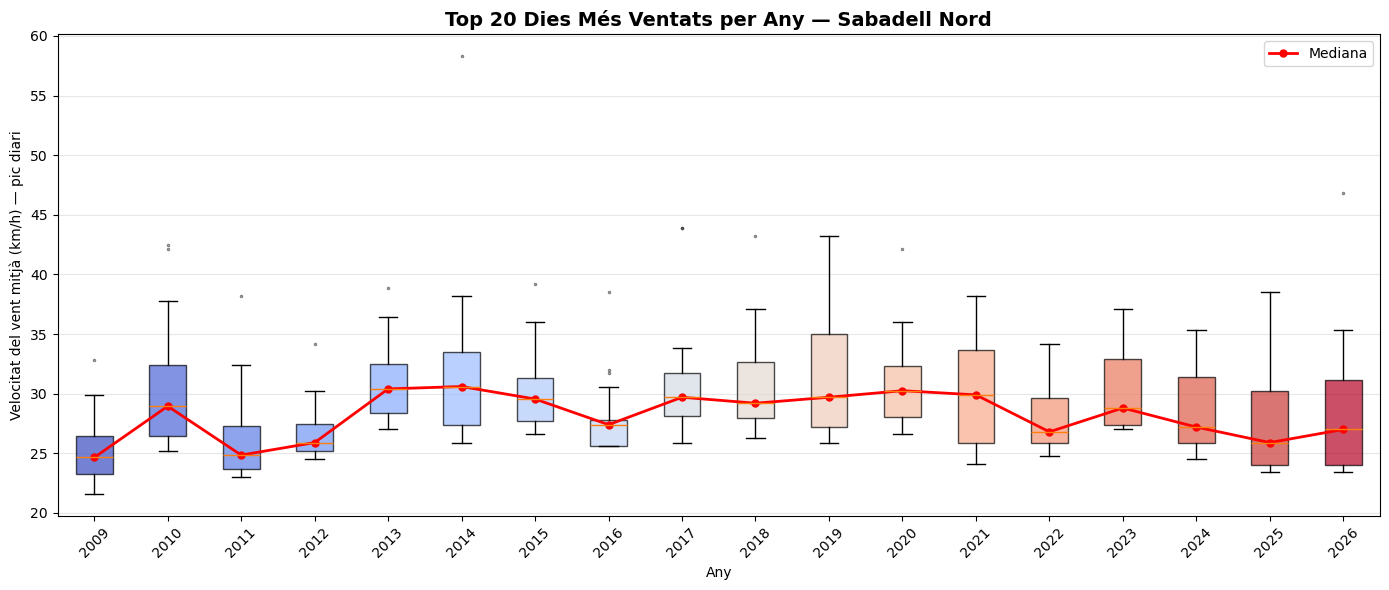

In [5]:
years_sorted = sorted(top20['year'].unique())
box_data = [
    top20[top20['year'] == y]['daily_max_wind'].values
    for y in years_sorted
]
medians = [np.median(d) for d in box_data]

fig, ax = plt.subplots(figsize=(14, 6))

bp = ax.boxplot(
    box_data,
    labels=[str(y) for y in years_sorted],
    patch_artist=True,
    showfliers=True,
    flierprops=dict(marker='.', markersize=3, alpha=0.5)
)

# Color gradient per any
norm = plt.Normalize(min(years_sorted), max(years_sorted))
cmap = plt.cm.coolwarm

for patch, year in zip(bp['boxes'], years_sorted):
    patch.set_facecolor(cmap(norm(year)))
    patch.set_alpha(0.7)

# Línia de la mediana
ax.plot(range(1, len(years_sorted) + 1), medians, color='red', linewidth=2, marker='o', markersize=5, label='Mediana')

ax.set_title(
    'Top 20 Dies Més Ventats per Any — Sabadell Nord',
    fontsize=14,
    fontweight='bold'
)
ax.set_xlabel('Any')
ax.set_ylabel('Velocitat del vent mitjà (km/h) — pic diari')
ax.set_xticklabels([str(y) for y in years_sorted], rotation=45)
ax.grid(axis='y', alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

### 5.1 Mann-Kendall sobre les Medianes

Test de tendència de Mann-Kendall aplicat a les medianes dels top 20 de cada any.

In [9]:
import sys
sys.path.insert(0, r"..\..\scripts" if sys.platform == "win32" else "../../scripts")
from statistical_tests import mk_analysis_series, print_mk_table

result = mk_analysis_series(
    np.array(years_sorted),
    np.array(medians),
    'Mediana top 20 wind_avg per year'
)
print(result['summary'])
print_mk_table([result])

--- Mediana top 20 wind_avg per year ---
  Mann-Kendall tau = -0.0066, p = 0.9697 (no trend)
  Sen's slope = 0.0000 per year [-0.2400, 0.1808]
  Pettitt change point: index=4, year~2013, p=1.0000 (not significant)
  Significant at: alpha=0.05 no, alpha=0.01 no
Label                                              tau   MK p-value      Slope Trend           Sig 0.05  CP year
----------------------------------------------------------------------------------------------------------------
Mediana top 20 wind_avg per year               -0.0066     0.9697     0.0000 no trend               N     2013


## 6. Hora del Pic de Vent

Quan mirem els top 20 dies de cada any, a quina hora del dia es produeix el pic de `wind_avg`? Aquest histograma acumula tots els anys per veure el patró horari.

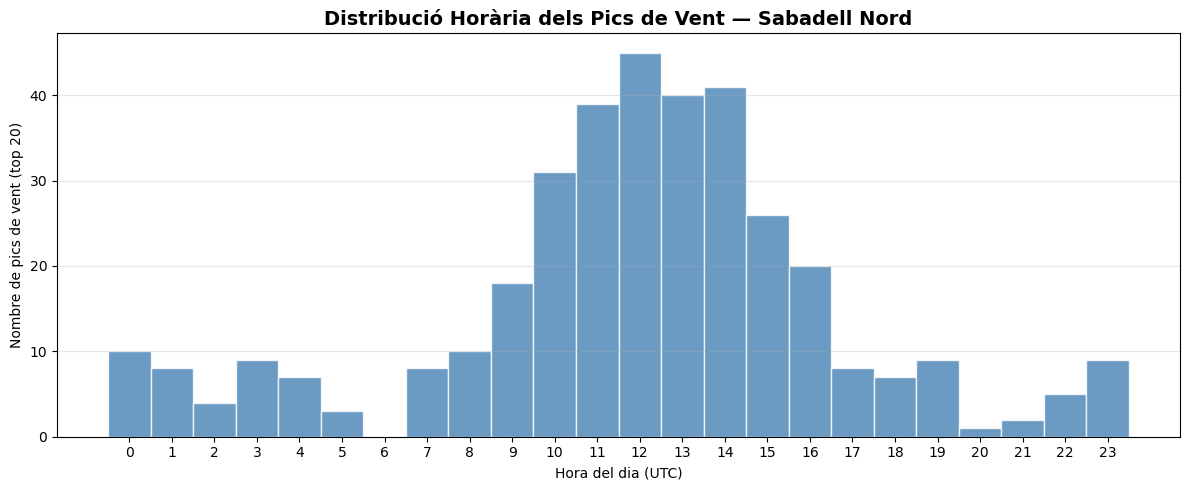

In [10]:
fig, ax = plt.subplots(figsize=(12, 5))

# Histograma de les hores dels pics de vent (top 20 de tots els anys)
hours = top20['hour'].values
bins = np.arange(-0.5, 24.5, 1)

ax.hist(hours, bins=bins, color='steelblue', edgecolor='white', alpha=0.8)
ax.set_xticks(range(0, 24))
ax.set_xlabel('Hora del dia (UTC)')
ax.set_ylabel('Nombre de pics de vent (top 20)')
ax.set_title('Distribució Horària dels Pics de Vent — Sabadell Nord', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 6.1 Hora del Pic per Any (Heatmap)

Com ha evolucionat l'hora del pic de vent any rere any?

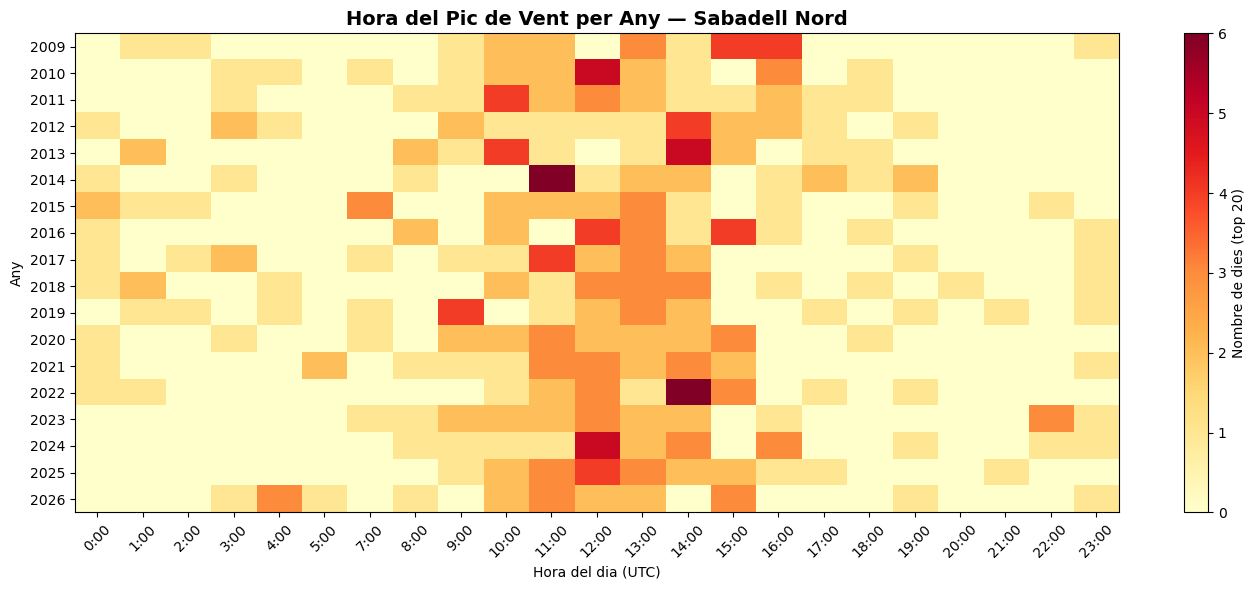

In [11]:
# Taula de contingència: any × hora
hour_pivot = top20.pivot_table(
    index='year', columns='hour', aggfunc='size', fill_value=0
)

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(hour_pivot.values, aspect='auto', cmap='YlOrRd')

ax.set_xticks(range(len(hour_pivot.columns)))
ax.set_xticklabels([f'{h}:00' for h in hour_pivot.columns], rotation=45)
ax.set_yticks(range(len(hour_pivot.index)))
ax.set_yticklabels([str(int(y)) for y in hour_pivot.index])

ax.set_xlabel('Hora del dia (UTC)')
ax.set_ylabel('Any')
ax.set_title('Hora del Pic de Vent per Any — Sabadell Nord', fontsize=14, fontweight='bold')

cbar = fig.colorbar(im, ax=ax, label='Nombre de dies (top 20)')

plt.tight_layout()
plt.show()

## 7. Estacionalitat dels Dies Ventats

En quins mesos tendeixen a caure els dies més ventats? Ho analitzem amb un heatmap any × mes.

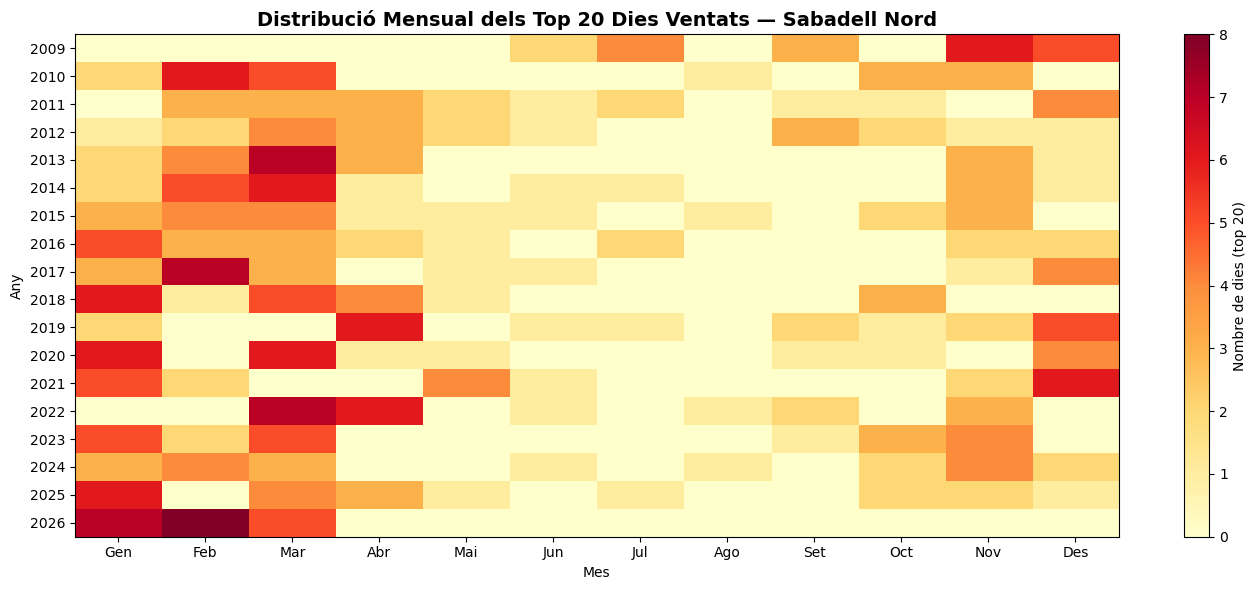

In [12]:
# Agrupar top 20 per any i mes
monthly_pivot = top20.pivot_table(
    index='year', columns='month', aggfunc='size', fill_value=0
)

month_names = ['Gen', 'Feb', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Oct', 'Nov', 'Des']

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(monthly_pivot.values, aspect='auto', cmap='YlOrRd')

ax.set_xticks(range(len(monthly_pivot.columns)))
ax.set_xticklabels([month_names[m-1] for m in monthly_pivot.columns])
ax.set_yticks(range(len(monthly_pivot.index)))
ax.set_yticklabels([str(int(y)) for y in monthly_pivot.index])

ax.set_xlabel('Mes')
ax.set_ylabel('Any')
ax.set_title('Distribució Mensual dels Top 20 Dies Ventats — Sabadell Nord', fontsize=14, fontweight='bold')

cbar = fig.colorbar(im, ax=ax, label='Nombre de dies (top 20)')

plt.tight_layout()
plt.show()

### 7.1 Distribució Mensual Agregada (Tots els Anys)

Acumulant tots els anys, quins mesos concentren més dies ventats?

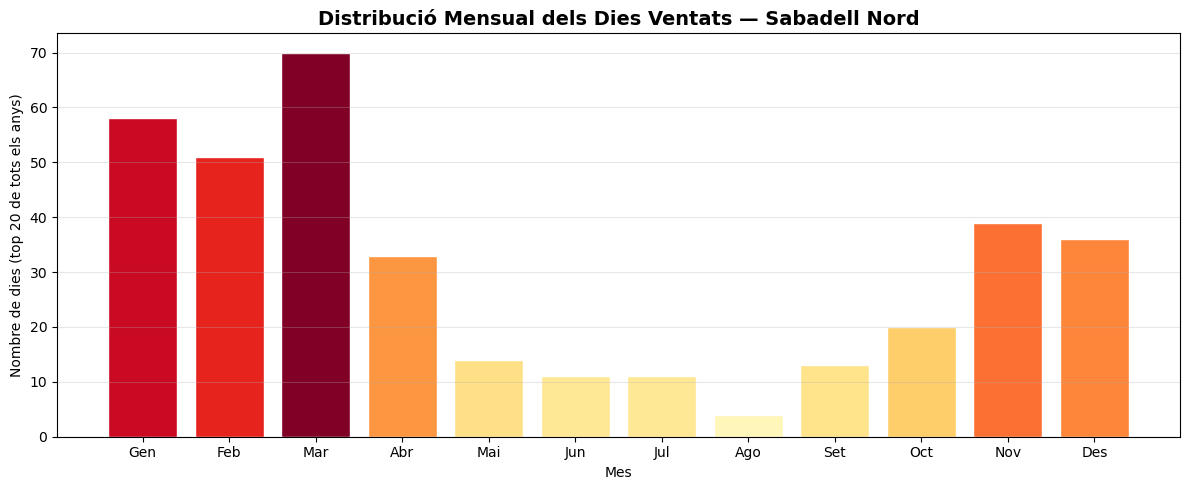

In [13]:
month_counts = top20.groupby('month').size()

fig, ax = plt.subplots(figsize=(12, 5))
colors = plt.cm.YlOrRd(month_counts.values / month_counts.max())

ax.bar(month_counts.index, month_counts.values, color=colors, edgecolor='white')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.set_xlabel('Mes')
ax.set_ylabel('Nombre de dies (top 20 de tots els anys)')
ax.set_title('Distribució Mensual dels Dies Ventats — Sabadell Nord', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()